# Relacion 5 Nanoelectrónica

### Ejercicio 1: Realizar ejercicio 5.1 de Marc Baldo.

### Ejercicio 2:

**Considere el hilo (Quantum Wire) de la siguiente figura: Este hilo presenta solo dos modos energéticos localizados en $E_{c1}=-4.7$ eV y en $E_{c2}=-4.6$ eV. Desarrolle una expresión analítica de la curva $I_{DS}-V_{DS}$ en función de $V_{GS} a T=0K. Represente la solución para 0<$V_{DS}$<0.5 en los casos $V_{GS}$ = 0.3V, 0.35V, 0.4V, 0.45V, 0.5V. Suponer $C_S=C_D= 0$, $C_G = 50$aF/nm y L=100nm**

In [46]:
### LIBRERIAS ########################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [47]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

h = 4.1357*10**(-15)        #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

m = 9.1*10**(-31)           #kg

In [48]:
### Definición de parámetros para los ejercicios ############################

T = 0               #K
KT = 0.026*T/300    #eV
L = 100             #nm
Ef0 = -5.0          #eV

mu_s0 = Ef0     
mu_d0 = Ef0

Cs = 0
Cd = 0
Cg = 50             #aF/nm


Vmax = 10.0         #V
numpasos = 801      #Cantidad de pasos desde -Vmax hasta Vmax
precision = 10**(-6)    #Precisión a la hora de converger U
alfa = 0.1              #Constante para la convergencia (Para valores mayores a 0.15 daba resultados raros)


#Creo el vector de voltajes y las energías

VGS_list = [0.3, 0.35, 0.4, 0.45, 0.5]
Ec_list = [-4.7, -4.6]
numpasosE=4000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Constantes físicas
# ==============================
q = 1.602176634e-19
h = 6.62607015e-34
kB_eV = 8.617333262e-5

# ==============================
# Parámetros
# ==============================
Ec_modes_0 = np.array([-4.7, -4.6])   # eV
EF = -5.0                             # eV
T = 1e-6                              # K
KT = kB_eV * T                        # eV
G0 = 2 * q**2 / h                     # A/V


def fermi(energia, e_fermi):
    """
    Args:
        energia (Float or array): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0/(1.0 + np.exp(x_clipped))        #Si no acoto por arriba y por abajo el programa tarda demasiado.


def num_open_modes(E, VGS):
    Ec_eff = Ec_modes_0 - VGS
    return np.sum(E >= Ec_eff)  #Esto es un array de true y false. Mira a ver si cumple el canal con energía E[i] si al quitarle VGS permite circular electrones, o todavía se queda por arriba.


def current_total(VGS, VDS, EF=EF):     #Uso la formula final de las diapositivas para calcular la intensidad. Ojo pero no la discreta, integro usando el trapecio.
    muS = EF
    muD = EF - VDS
    Ec_eff = Ec_modes_0 - VGS

    Emin = min(np.min(Ec_eff), muD, muS) - 0.2      #Pongo 0.2 porque el profe puso 0.2 para ver que todo se cumplía. Y efectivamente y de sobra.
    Emax = max(np.max(Ec_eff), muD, muS) + 0.2
    E = np.linspace(Emin, Emax, numpasosE)

    M = np.array([num_open_modes(e, VGS) for e in E], dtype=float)  #Vemos la cantidad de modos para cada energía. Barremos todas las energías y comprobamos. Esto sirve para ver los codos.
    fS = fermi(E, muS)
    fD = fermi(E, muD)

    return G0 * np.trapz(M * (fS - fD), E)  #Integro con trapecio porque sino con quad no funcionaba y con simpson tardaba muchísimo.


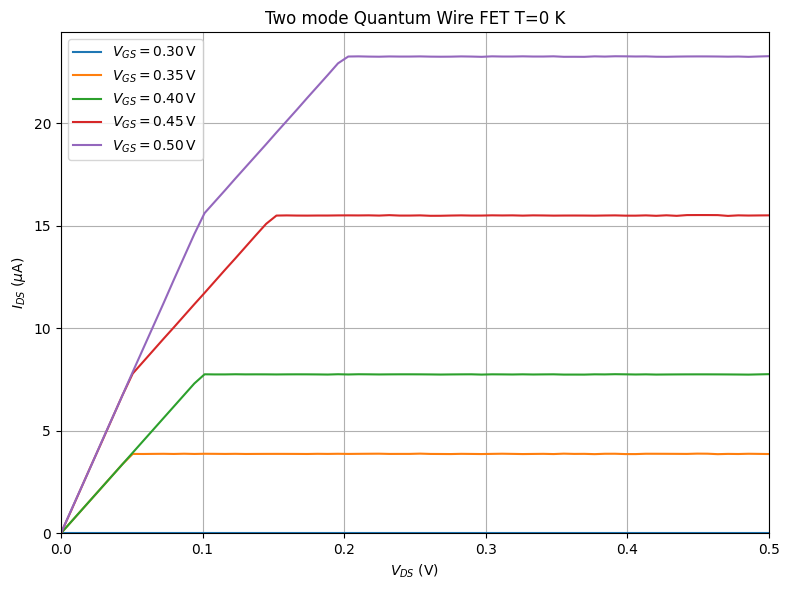

In [55]:
# ==============================
# Curvas a plotear
# ==============================
VGS_values = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 70)

plt.figure(figsize=(8, 6))

for VGS in VGS_values:
    IDS = np.array([current_total(VGS, VDS) for VDS in VDS_array])
    plt.plot(VDS_array, IDS * 1e6, label=fr"$V_{{GS}}={VGS:.2f}\,\mathrm{{V}}$")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ ($\mu$A)")
plt.title(r"Two mode Quantum Wire FET T=0 K")
plt.grid()
plt.legend()
plt.xlim(0, 0.5)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Funciones del programa #################### CODIGO QUE YA NO FUNCIONA
"""

#Nivel de energía de fermi
def fermi(energia, e_fermi):
    """
    Args:
        energia (Float): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    aux = (energia - e_fermi)/(KT + 1e-15)  #Como hay que integrar desde infinito y esto satura, hay que acotar un poco
    if aux < -100:
        return 1.0
    elif aux > 100:
        return 0.0
    else:
        resultado = 1/(1+np.exp((energia - e_fermi)/(KT+1e-15)))
        return resultado
    
    
#Densidad de estados

def densidad_g(energia, U_charging, E_c_aux):
    """

    Args:
        energia (float): variable energía
        U_charging (float): efecto de charging a esa energía
        E_c_aux (float): nivel de banda de conduccion
    """
    if energia > E_c_aux:
         return 2*L/h*np.sqrt(2*m/(energia-E_c_aux))*np.heaviside(energia-E_c_aux-U_charging, 0)
    else:
        return 0
   


#Corriente para cada modo

def corriente_modo(Vgs, Vds, E_c_aux, energia):
    """
    Args:
        Vgs (float): Voltaje puerta-fuente
        Vds (float): voltaje drenador-fuente
        E_c_aux (float): nivel de banda de conducción
        energia (array): linspace de energía
    """
    
    mu_s = mu_s0 + Vds/2
    mu_d = mu_d0 - Vds/2
    
    # Como Cg >> Cd y Cs, estamos en ZCL --> U approx -q*VGS
    # En eV queda U_charging = -Vgs
    U_charging = -Vgs

    aux = 2*q/h
    integrando = []

    for E in energia:
        g = densidad_g(E, U_charging, E_c_aux)
        f_s = fermi(E, mu_s)
        f_d = fermi(E, mu_d)

        integrando.append(aux*g*(f_s - f_d))

    integrando = np.array(integrando)

    integral = np.trapz(integrando, energia)    #Integro con trapezoid porque no me va con quad
    return integral
     
def corriente_total(Vgs, Vds, energia):
    I = 0.0
    for Ec in Ec_list:
        I = I + corriente_modo(Vgs, Vds, Ec, energia)
    return I

